# Taller 5 · Entropía y codificación Huffman

**Asignatura:** Teoría de la Información y Procesado de Señal  
**Grado en Ciencia e Ingeniería de Datos (GCED) — Universidad de A Coruña**  
**Duración:** 2 horas  
**Modalidad:** Jupyter Notebook con asistencia de IA (incluye helper `Huffman_TI.py`)

---

## Objetivos de aprendizaje

Al finalizar este taller serás capaz de:

1. Estimar **frecuencias y probabilidades** de símbolos a partir de una secuencia.
2. Calcular la **auto-información** $I(s_i) = -\log_2(p(s_i))$ y relacionarla con la "sorpresa".
3. Calcular la **entropía** $H$ como promedio ponderado de auto-información.
4. Verificar las **propiedades de la entropía**: $H \geq 0$, $H \leq \log_2(K)$.
6. Construir un **código Huffman** y evaluar su longitud media $\bar{L}$, eficiencia $\eta$ y redundancia.
7. Relacionar Huffman con el **Primer Teorema de Shannon**: $H \leq \bar{L} < H + 1$.
8. Comparar con código fijo: calcular **ganancia de compresión**.
9. Analizar la entropía de imágenes y su relación con la compresión.

---

## 🎯 Reto central del taller

> **¿Por qué la entropía es un límite infranqueable para la longitud media de cualquier código? ¿Cómo se acerca Huffman a ese límite y cuándo apenas mejora respecto a un código de longitud fija?**


## Metodología de trabajo con IA (recordatorio)

- Puedes usar IA para generar código, pero **cada bloque** requiere: validación + explicación.
- No te limites a imprimir números: **interpreta** auto-información, entropía, longitud media y eficiencia.
- Si algo no cuadra: revisa normalización de probabilidades, símbolos fuera del diccionario, tipos (str vs int).
- **Genera → Valida → Explica**: este ciclo se repite en cada bloque.


---

## Identificación del estudiante

Completa los siguientes campos con tu información personal:

- **Apellidos:** Martínez Martínez

- **Nombre:** Jimena

- **Email UDC:** jimena.martinez@udc.es


In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
import pandas as pd
import sys
from pathlib import Path
from matplotlib.image import imread
from IPython.display import display, Markdown
import ipywidgets as widgets

np.random.seed(42)

print("✓ Entorno listo")


✓ Entorno listo


---

## 0. Cargar el helper de Huffman · Conexión con Taller 4

### Conexión con el Taller anterior

> En el Taller 4 vimos cómo DPCM y Delta Modulation explotan la **redundancia temporal** 
> (muestras consecutivas similares → diferencias pequeñas → menos bits). 
> Ahora abordaremos la **redundancia estadística**: si algunos símbolos son más probables que otros, 
> podemos asignarles códigos más cortos. La **entropía** nos dirá el **límite teórico** de cuánto 
> podemos comprimir, y **Huffman** nos dará un código que se acerca a ese límite.

### Helper `Huffman_TI.py`

Este taller usa un helper: `Huffman_TI.py` (disponible en el repositorio).

La clase `Huffman` proporciona:
- `Huffman(freq_dict)`: Constructor con diccionario de frecuencias o probabilidades.
- `.codigo`: Diccionario símbolo → código binario (string).
- `.codifica(secuencia)`: Codifica una secuencia.
- `.decodifica(bitstring)`: Decodifica un bitstring.


In [2]:
# Intenta importar el helper
try:
    # Add the helpers directory to the Python path
    helpers_path = Path('..') / 'helpers'
    if helpers_path.exists():
        sys.path.insert(0, str(helpers_path.resolve()))
    from Huffman_TI import Huffman
    print("✓ Helper Huffman_TI cargado")
except ImportError:
    print("⚠ No se encontró Huffman_TI.py")
    print("Asegúrate de que el archivo está en el directorio helpers al mismo nivel del directorio que contiene este cuaderno.")

✓ Helper Huffman_TI cargado


---

## 1. Fuente discreta y estimación de probabilidades

### Contexto teórico

Una **fuente discreta** emite símbolos de un alfabeto $\mathcal{A} = \{s_1, s_2, \ldots, s_K\}$ 
con probabilidades $\{p_1, p_2, \ldots, p_K\}$.

A partir de una secuencia observada, estimamos:
- **Frecuencia:** número de veces que aparece cada símbolo.
- **Probabilidad:** frecuencia normalizada (suma = 1).

---

#### 📝 Hipótesis previa (COMPLETA ANTES de implementar/ejecutar)

**Preguntas:**

- Si un símbolo aparece el 50% de las veces, ¿cuántos bits necesitarías *idealmente* para representarlo? (piensa en la cantidad de información que tendría) 1 bit, porque tiene poca sorpresa y aparece muy frecuentemente.
- ¿Y si aparece solo el 1% de las veces? (piensa en la cantidad de información que tendría) Necesitaría muchos más bits porque es un evento raro y tiene mucha información.
- ¿Qué símbolo crees que tendrá menos información en la cadena `"abracadabra es una palabra mágica que usan los magos"`? El espacio " " o la letra "a", porque aparecen más veces.


### Bloque 1 · Construir diccionario de frecuencias/probabilidades

**Tareas:**
1. Elige una secuencia de símbolos (texto o lista de enteros).
2. Calcula el diccionario de frecuencias `freq[s]`.
3. Calcula el diccionario de probabilidades `p[s] = freq[s] / N`.
4. Verifica que $\sum p = 1$.


In [3]:
# === IMPLEMENTACIÓN ===

# Secuencia de texto para analizar
x = "abracadabra es una palabra magica que usan los magos"

# TODO: Calcula N (longitud de la secuencia)
N = len(x)

# TODO: Construye un diccionario de frecuencias,'freq', donde:
#   - clave = cada símbolo que aparece en x
#   - valor = número de veces que aparece ese símbolo (frecuencia/conteo).
# Recorre x; para cada símbolo, si ya está en freq súmale 1, si no, ponlo con valor 1.
freq = {}
for s in x: 
    if s in freq:
        freq[s] +=1
    else:
        freq[s] = 1

# TODO: Calcula el tamaño del alfabeto, K, a partir de freq
K = len(freq) 

# TODO: Calcula probabilidades para cada símbolo a partir de su frecuencia
p = {}
for s in freq:
    p[s] = freq[s] / N

In [4]:
# === VALIDACIÓN ===
assert N == len(x)
assert abs(sum(p.values()) - 1.0) < 1e-9, "Las probabilidades deben sumar 1"
assert all(v > 0 for v in p.values()), "Todas las probabilidades deben ser positivas"
assert K == len(set(x)) , "K debe coincidir con el tamaño del alfabeto"

# Muestra resultados
print(f"Longitud de secuencia: N = {N}")
print(f"Tamaño del alfabeto: K = {K}")
print(f"\nFrecuencias y probabilidades:")
print(f"{'Símbolo':<10} {'Freq':>6} {'Prob':>10}")
print("-" * 28)
for s in sorted(p.keys(), key=lambda k: p[k], reverse=True):
    print(f"{repr(s):<10} {freq[s]:>6} {p[s]:>10.4f}")

print(f"\n✓ sum(p) = {sum(p.values()):.6f}")


Longitud de secuencia: N = 52
Tamaño del alfabeto: K = 17

Frecuencias y probabilidades:
Símbolo      Freq       Prob
----------------------------
'a'            13     0.2500
' '             8     0.1538
's'             4     0.0769
'b'             3     0.0577
'r'             3     0.0577
'u'             3     0.0577
'c'             2     0.0385
'e'             2     0.0385
'n'             2     0.0385
'l'             2     0.0385
'm'             2     0.0385
'g'             2     0.0385
'o'             2     0.0385
'd'             1     0.0192
'p'             1     0.0192
'i'             1     0.0192
'q'             1     0.0192

✓ sum(p) = 1.000000


### ✍️ Explicación (OBLIGATORIA)

1. ¿Por qué es equivalente usar frecuencias o probabilidades para construir el código Huffman?

   Porque las probabilidades se obtienen normalizando las frecuencias (dividiendo entre el total de símbolos). El algoritmo de Huffman solo necesita conocer la relación de frecuencia entre los símbolos, por lo que usar frecuencias o probabilidades produce el mismo árbol y los mismos códigos.  

2. ¿Qué símbolo es más frecuente? ¿Coincide con tu hipótesis?

   El símbolo más frecuente es 'a', con frecuencia 13 y probabilidad 0.25.
   Sí coincide con la hipótesis, ya que los símbolos más frecuentes aparecen más veces y por tanto tienen menor cantidad de información.

3. ¿Qué diferencia hay entre la longitud del mensaje y la del alfabeto?

   La longitud del mensaje (N) es el número total de símbolos en la secuencia.
   El tamaño del alfabeto (K) es el número de símbolos distintos que aparecen en la secuencia.
   Es decir, N cuenta todos los símbolos, mientras que K solo los diferentes.

---

## 2. Auto-información: la "sorpresa" de un símbolo

### Contexto teórico

Antes de definir la entropía, necesitamos el concepto de **auto-información** (o información propia), que mide la información asociada a la aparición de **un único símbolo** \(s_i\):

$$I(s_i) = -\log_2(p(s_i)) = \log_2\left(\frac{1}{p(s_i)}\right) \quad \text{(bits)}$$

**Propiedades clave:**
- $I(s) \geq 0$ siempre (no existe información negativa).
- Si $p(s) = 1$ (evento seguro) → $I(s) = 0$ (no aporta información).
- Si $p(s) \to 0$ (evento casi imposible) → $I(s) \to \infty$ (máxima sorpresa).
- A menor probabilidad, **mayor información** (mayor sorpresa).

**Intuición:** "Que llueva en el desierto del Sahara" ($p$ muy baja) aporta mucha más información 
que "que salga el sol en verano" ($p \approx 1$).

---

#### 📝 Hipótesis previa (COMPLETA ANTES de implementar/ejecutar)

**Preguntas:**

- Si $p(s) = 0.5$, la auto-información será $I(s)$ = 1 bits
- Si $p(s) = 0.25$, será $I(s)$ = 2 bits
- Si $p(s) = 1/8$, será $I(s)$ = 3 bits
- ¿Ves el patrón? Con probabilidad $1/2^n$, la auto-información es n bits
- ¿I(s) es creciente o decreciente cuando aumenta p(s)? ¿Qué ocurre con I cuando p se acerca a 0 y cuando p se acerca a 1? ¿Qué forma tiene? Decreciente cuando aumenta la probabilidad. Cuando p -> 0, la auto-información tiende a infinito. Cuando p -> 1, la auto-información tiende a 0. La forma de la función es logarítmica decreciente.


### Bloque 2 · Cálculo de auto-información

**Tareas:**
1. Implementa la función de auto-información.
2. Calcula $I(s_i)$ para cada símbolo del Bloque 1.
3. Grafica $I(s)$ vs $p(s)$ — observa la relación.
4. Calcula el promedio ponderado $\sum p_i \cdot I(s_i)$: ¡esto es la entropía!


In [5]:
# === IMPLEMENTACIÓN: Auto-información ===

def auto_informacion(prob):
    """
    Calcula la auto-información de un símbolo.
    
    Parámetros:
        prob: probabilidad del símbolo (0 < prob <= 1)
    
    Retorna:
        I: auto-información en bits
    """
    # TODO: Obten la auto-información de un símbolo, I, a partir de su probabilidad
    I = -math.log2(prob)

    return I

# Calcula I(s) para cada símbolo
info = {s: auto_informacion(p[s]) for s in p}

In [6]:
# === VALIDACIÓN ===
assert abs(auto_informacion(0.5) - 1.0) < 1e-9, "I(0.5) debe ser 1 bit"
assert abs(auto_informacion(0.25) - 2.0) < 1e-9, "I(0.25) debe ser 2 bits"
assert abs(auto_informacion(1.0) - 0.0) < 1e-9, "I(1.0) debe ser 0 bits"
assert all(v >= 0 for v in info.values()), "Auto-información siempre >= 0"

# Verifica casos límite
print(f"Verificación en casos de ejemplo:")
print(f"  I(p=0.25)  = {auto_informacion(0.25):.4f} bits (esperado: 2.0)")
print(f"  I(p=0.5) = {auto_informacion(0.5):.4f} bits (esperado: 1.0)")
print(f"  I(p=0.75) = {auto_informacion(0.75):.4f} bits (esperado: 0.4150)")
print(f"  I(p=1.0)  = {auto_informacion(1.0):.4f} bits (esperado: 0.0)")

# Muestra resultados (ordenados por probabilidad)
print(f"\n{'Símbolo':<10} {'p(s)':>8} {'I(s) bits':>10}")
print("-" * 30)
for s in sorted(p.keys(), key=lambda k: p[k], reverse=True):
    print(f"{repr(s):<10} {p[s]:>8.4f} {info[s]:>10.4f}")

Verificación en casos de ejemplo:
  I(p=0.25)  = 2.0000 bits (esperado: 2.0)
  I(p=0.5) = 1.0000 bits (esperado: 1.0)
  I(p=0.75) = 0.4150 bits (esperado: 0.4150)
  I(p=1.0)  = -0.0000 bits (esperado: 0.0)

Símbolo        p(s)  I(s) bits
------------------------------
'a'          0.2500     2.0000
' '          0.1538     2.7004
's'          0.0769     3.7004
'b'          0.0577     4.1155
'r'          0.0577     4.1155
'u'          0.0577     4.1155
'c'          0.0385     4.7004
'e'          0.0385     4.7004
'n'          0.0385     4.7004
'l'          0.0385     4.7004
'm'          0.0385     4.7004
'g'          0.0385     4.7004
'o'          0.0385     4.7004
'd'          0.0192     5.7004
'p'          0.0192     5.7004
'i'          0.0192     5.7004
'q'          0.0192     5.7004


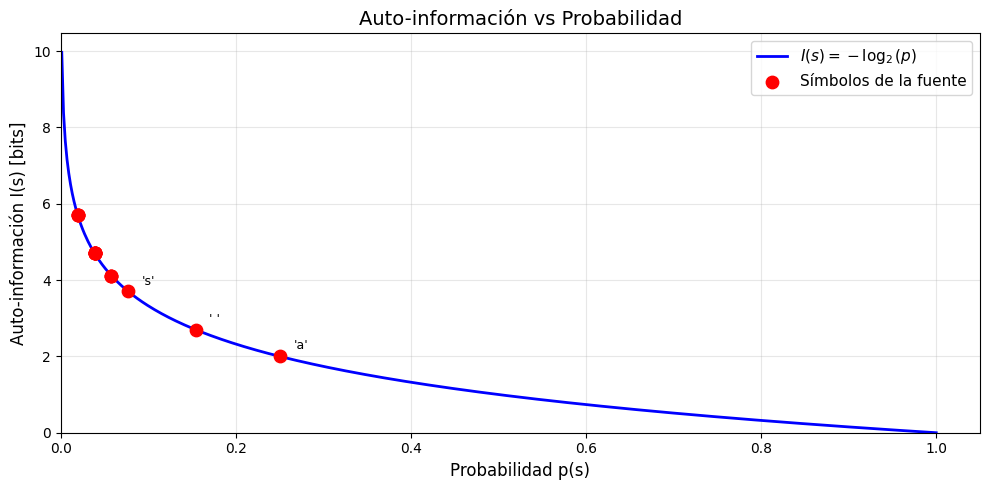

In [7]:
# === GRÁFICA: I(s) vs p(s) ===

# Curva teórica
p_range = np.linspace(0.001, 1.0, 500)
I_range = -np.log2(p_range)

# Puntos de nuestros símbolos
p_vals = np.array([p[s] for s in p])
I_vals = np.array([info[s] for s in p])

plt.figure(figsize=(10, 5))
plt.plot(p_range, I_range, 'b-', linewidth=2, label='$I(s) = -\\log_2(p)$')
plt.scatter(p_vals, I_vals, c='red', s=80, zorder=5, label='Símbolos de la fuente')

# Marca algunos puntos especiales
for s in sorted(p.keys(), key=lambda k: p[k], reverse=True)[:3]:
    plt.annotate(repr(s), (p[s], info[s]), textcoords="offset points",
                 xytext=(10, 5), fontsize=9)

plt.xlabel('Probabilidad p(s)', fontsize=12)
plt.ylabel('Auto-información I(s) [bits]', fontsize=12)
plt.title('Auto-información vs Probabilidad', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xlim([0, 1.05])
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()


### ✍️ Explicación (OBLIGATORIA)

1. ¿Por qué usamos $\log_2$ y no otro logaritmo? ¿Qué unidades tendríamos con $\ln$?

   Usamos log2, porque medimos la información en bits, que son las unidades naturales en sistemas digitales.

2. ¿Por qué un evento seguro ($p=1$) aporta cero información?

   Porque si un evento ocurre con probabilidad 1 no hay sorpresa al observarlo. No necesitamos transmitir ninguna información adicional para saber que ocurrirá.

3. ¿Qué relación hay entre la auto-información $I(s)$ y el número ideal de bits para representar $s$?

   La auto-información I(s) indica cuántos bits idealmente necesitaríamos para representar ese símbolo. 
   Los símbolos con menor probabilidad requieren más bits, mientras que los más probables requieren menos bits.


### 🔍 Checkpoint del profesor (Parada 1)

- [ ] Frecuencias y probabilidades correctas ($\sum p = 1$)
- [ ] Auto-información calculada para todos los símbolos
- [ ] Gráfica $I(s)$ vs $p(s)$ muestra curva decreciente (forma logarítmica)
- [ ] El estudiante verifica que $\sum p_i \cdot I(s_i) = H$
- [ ] El estudiante entiende que entropía = promedio de auto-información


---

## 3. Entropía de la fuente

### Contexto teórico

La **entropía** de una fuente discreta mide la incertidumbre promedio (o la auto-información media):

$$H(S) = -\sum_{i=1}^{K} p_i \log_2(p_i) = \sum_{i=1}^{K} p_i \cdot I(s_i) \quad \text{(bits/símbolo)}$$

**Propiedades fundamentales:**
- $H \geq 0$ (siempre no negativa).
- $H = 0$ solo si un símbolo tiene $p = 1$ (fuente determinista → sin incertidumbre).
- $H \leq \log_2(K)$ (máximo cuando **todos** los símbolos son equiprobables).
- $H = \log_2(K)$ si y solo si $p_i = 1/K$ para todo $i$ (distribución uniforme).

**Interpretación:** $H$ es el **límite inferior teórico** para la longitud media de cualquier código. 
No existe ningún código (por muy inteligente que sea) con $\bar{L} < H$.

---

#### 📝 Hipótesis previa (COMPLETA ANTES de implementar/ejecutar)

**Preguntas:**

- Con $K = 8$ símbolos, ¿cuál es la entropía máxima posible? $H_{\max}$ = log2(K) bits/símbolo
- ¿Qué distribución alcanza ese máximo? p(s) = 1/K
- Si un solo símbolo tiene $p = 0.99$, ¿la entropía será alta o baja? Será 0, porque no hay incertidumbre.
- Analiza por qué la entropía máxima es $\log_2(K)$ Porque cuando todos los símbolos son igual de probables, la incertidumbre es máxima. En ese caso necesitamos log2(K) bits para distinguir entre los K posibles símbolos.
- ¿Por qué la entropía no puede ser negativa? Analízalo desde el punto de vista matemático y desde el punto de vista del significado de la entropía Como 0 < p(s) <= 1, entonces el log es menor o igual a 0, y al multiplicar por -, todos los términos pasan a ser positivos.
La entropía mide cantidad de información promedio, y la información no puede ser negativa.


### Bloque 3 · Cálculo de entropía y exploración de propiedades

**Tareas:**
1. Implementa el cálculo de entropía.
2. Calcula la cota superior $\log_2(K)$.
3. Verifica que $H \leq \log_2(K)$.

In [8]:
# === IMPLEMENTACIÓN: Entropía ===

def calcular_entropia(probabilidades):
    """
    Calcula la entropía de una distribución.
    
    Parámetros:
        probabilidades: dict o array de probabilidades
    
    Retorna:
        H: entropía en bits/símbolo
    """
    # Obtiene las probabilidades dependiendo de si es un diccionario o un array
    if isinstance(probabilidades, dict):
        probs = np.array(list(probabilidades.values()))
    else:
        probs = np.array(probabilidades)
    
    
    # TODO: Calcula la entropía, H
    H = -np.sum(probs * np.log2(probs))
    
    return H

In [9]:
# Calcula entropía de nuestra fuente
H = calcular_entropia(p)

#TODO: Calcula la cota superior de H, H_max
H_max = np.log2(K)

In [10]:
# === VALIDACIÓN ===
assert H >= 0, "La entropía debe ser no negativa"
assert H <= H_max + 1e-6, "H debe ser <= log₂(K)"

print(f"Entropía H = {H:.4f} bits/símbolo")
print(f"Cota superior H_max = log₂(K) = {H_max:.4f} bits/símbolo")
print(f"Eficiencia relativa H/H_max = {H/H_max:.4f}")
print(f"\n→ La fuente tiene {(1 - H/H_max)*100:.1f}% de redundancia estadística")

Entropía H = 3.6164 bits/símbolo
Cota superior H_max = log₂(K) = 4.0875 bits/símbolo
Eficiencia relativa H/H_max = 0.8848

→ La fuente tiene 11.5% de redundancia estadística


### ✍️ Explicación (OBLIGATORIA)

1. ¿Qué significa que $H \leq \log_2(K)$? ¿En qué caso se alcanza la igualdad?

   Significa que la entropía de una fuente no puede superar la entropía de una distribución uniforme.
   La igualdad se alcanza cuando todos los símbolos tienen la misma probabilidad, es decir:
   p(s) = 1/K

2. ¿Por qué la entropía se considera el "límite teórico" de compresión?

   Porque representa la cantidad mínima promedio de bits necesarios para codificar los símbolos de la fuente.
   



---

## 4. Código Huffman: construcción y análisis

### Contexto teórico

El algoritmo de Huffman alcanza la mínima longitud media alcanzable por cualquier código unívocamente decodificable:

1. Ordena los símbolos por probabilidad descendente (manteniendo el orden original en caso de empate).
2. Fusiona los dos de menor probabilidad en un nuevo nodo cuya probabilidad es la suma y reinsértalo manteniendo la ordenación descendente; en caso de empate, el nodo recién creado queda por encima de los ya existentes con la misma probabilidad.
3. Repite hasta tener un solo nodo (raíz).
4. Asigna 0/1 a cada rama del árbol; el código de cada símbolo es el camino desde la raíz hasta su hoja.

**Nota (desempate en el paso 2):** Si no fijáramos el criterio de desempate, podrían aparecer árboles distintos, pero todos con la misma longitud media mínima. La regla que usamos (colocar el nodo recién creado por encima en caso de igualdad) solo garantiza que todos obtengamos exactamente el mismo árbol cuando existan empates.


**Resultado:** Los símbolos más probables quedan cerca de la raíz (códigos cortos) 
y los menos probables quedan lejos (códigos largos).

**Longitud media:** $\bar{L} = \sum_{i=1}^{K} p_i \cdot l_i$

---

#### 📝 Hipótesis previa (COMPLETA ANTES de implementar/ejecutar)

**Preguntas:**

- El símbolo más probable, ¿tendrá el código más corto o más largo? Más corto.
- ¿Cuál es el valor máximo de la eficiencia? 1 (100%)

### Bloque 4a · Construcción del código y métricas

**Tareas:**
1. Construye el código Huffman usando el helper.
2. Muestra la tabla de códigos ordenada por probabilidad.
3. Calcula $\bar{L}$.

In [11]:
# === IMPLEMENTACIÓN: Código Huffman ===

# Construye el codec Huffman
codec = Huffman(freq)

# Obtén el diccionario de códigos
code = codec.codigo

# Calcula longitudes
longitudes = {s: len(code[s]) for s in code}

# TODO: Calcula longitud media L
L = sum(p[s] * longitudes[s] for s in p)

# TODO: calcula el número total de dígitos binarios para la secuencia original, L_total, utilizando el código Huffman
L_total = sum(freq[s] * longitudes[s] for s in freq)

### Bloque 4b · Suposición de igualdad de probabilidades

Para comparar, vamos a considerar que los símbolos de nuestro ejemplo hubiesen tenido la misma probabilidad. 

Calcularemos:
- La longitud media. NOTA: **NO uses codificación Huffman**. Esto se cálcula de forma inmediata con lo que vimos en las explicaciones anteriores.
- La longitud total de la secuencia original en ese caso.

In [12]:
# TODO: Calcula la longitud media para el caso de que todos los símbolos tuvieran la misma probabilidad, L_fijo
K = len(p)
B_fijo = math.ceil(math.log2(K))
L_fijo = B_fijo

# TODO: calcula el número total de dígitos binarios para la secuencia original, L_total_fijo, utilizando el código fijo
N = sum(freq.values())
L_total_fijo = N * B_fijo


In [13]:
# === VALIDACIÓN ===
assert set(p.keys()).issubset(set(code.keys())), "Todos los símbolos deben estar codificados"
assert all(len(b) > 0 for b in code.values()), "Ningún código vacío"
assert L >= H - 1e-9, "L̄ debe ser >= H"
assert L_total <= L_total_fijo, "El código Huffman debe ser más eficiente que el código fijo"

# Muestra resultados
rows = [
    ("Entropía H",                H, "bits/símbolo"),
    ("Longitud media L código Huffman", L, "bits/símbolo"),
    ("Longitud media L código fijo", L_fijo, "bits/símbolo"),
    ("Longitud total de la secuencia con código Huffman", L_total, "dígitos"),
    ("Longitud total de la secuencia con código fijo", L_total_fijo, "dígitos"),
]

col1_w = 50
col2_w = 18
col3_w = 15

print("\n{:<{c1}}{:>{c2}}{:>{c3}}".format("Métrica", "Valor", "Unidad", c1=col1_w, c2=col2_w, c3=col3_w))
print("-" * (col1_w + col2_w + col3_w))

for name, value, unit in rows:
    if isinstance(value, int):
        value_fmt = f"{value:d}"
    else:
        value_fmt = f"{value:.4f}"
    print(f"{name:<{col1_w}}{value_fmt:>{col2_w}}{unit:>{col3_w}}")

# Ganancia
ganancia_relativa = (L_fijo - L) / L_fijo * 100
ganancia_absoluta = L_total_fijo - L_total
print(f"\nGanancia relativa por usar Huffman en vez de código fijo: {ganancia_relativa:.1f}%")
print(f"Ganancia absoluta por usar Huffman en vez de código fijo: {ganancia_absoluta} digitos binarios")

# Muestra códigos (ordenados por probabilidad)
print(f"\n{'Símbolo':<10} {'p(s)':>8} {'I(s)':>8} {'Código':<15} {'l(s)':>6}")
print("-" * 52)
for s in sorted(p.keys(), key=lambda k: p[k], reverse=True):
    print(f"{repr(s):<10} {p[s]:>8.4f} {info[s]:>8.2f} {code[s]:<15} {longitudes[s]:>6}")




Métrica                                                        Valor         Unidad
-----------------------------------------------------------------------------------
Entropía H                                                    3.6164   bits/símbolo
Longitud media L código Huffman                               3.6538   bits/símbolo
Longitud media L código fijo                                       5   bits/símbolo
Longitud total de la secuencia con código Huffman                190        dígitos
Longitud total de la secuencia con código fijo                   260        dígitos

Ganancia relativa por usar Huffman en vez de código fijo: 26.9%
Ganancia absoluta por usar Huffman en vez de código fijo: 70 digitos binarios

Símbolo        p(s)     I(s) Código            l(s)
----------------------------------------------------
'a'          0.2500     2.00 10                   2
' '          0.1538     2.70 010                  3
's'          0.0769     3.70 0011                 4
'b'   

In [14]:
# === VISUALIZACIÓN: Árbol de Huffman (ASCII) ===

def _build_tree(codes):
    root = {}
    for sym, bits in codes.items():
        node = root
        for bit in bits:
            node = node.setdefault(bit, {})
        node['_leaf'] = sym
    return root

def _render(node, p, code, prefix="", is_root=True):
    lines = []
    if '_leaf' in node:
        sym = node['_leaf']
        lines.append(f"{prefix}[{repr(sym):>3}]  p={p[sym]:.4f}  código={code[sym]}")
        return lines
    lines.append(f"{prefix}{'(root)' if is_root else '(·)'}")
    children = [(bit, node[bit]) for bit in ('0', '1') if bit in node]
    for i, (bit, child) in enumerate(children):
        is_last = (i == len(children) - 1)
        connector = "└── " if is_last else "├── "
        extension = "    " if is_last else "│   "
        child_lines = _render(child, p, code, prefix + extension, is_root=False)
        first = child_lines[0]
        lines.append(prefix + connector + f"{bit}: " + first[len(prefix + extension):])
        lines.extend(child_lines[1:])
    return lines

print("\n=== ÁRBOL DE HUFFMAN (0=izq, 1=der) ===\n")

texto = "\n".join("  " + line for line in _render(_build_tree(code), p, code))
texto += "\n\n→ Símbolos solo en hojas"

out = widgets.Textarea(
    value=texto,
    layout=widgets.Layout(width='100%', height='600px'),
    disabled=True
)
display(out)


=== ÁRBOL DE HUFFMAN (0=izq, 1=der) ===



Textarea(value="  (root)\n  ├── 0: (·)\n  │   ├── 0: (·)\n  │   │   ├── 0: (·)\n  │   │   │   ├── 0: (·)\n  │ …

### ✍️ Explicación (OBLIGATORIA)

1. ¿Los símbolos más probables tienen códigos más cortos? ¿Coincide con tu hipótesis?

   Sí. En el código Huffman los símbolos con mayor probabilidad aparecen más cerca de la raíz del árbol y, por tanto, tienen códigos más cortos. Esto coincide con la hipótesis inicial, ya que el algoritmo busca minimizar la longitud media del código asignando menos bits a los símbolos más frecuentes.


2. Compara $l(s)$ con $I(s)$ para cada símbolo. ¿Son iguales? ¿Por qué no pueden serlo siempre?

   No son exactamente iguales. 
   I(s) = -log2(p(s)) representa la longitud ideal de un código según la teoría de la información. Sin embargo, las longitudes reales deben ser enteras, por lo que Huffman aproxima estos valores redondeándoloes. Por eso pueden diferir ligeramente.


---

### Bloque 4c · Relación entre entropía y longitud media del código

**Tareas:**
1. Calcular la eficiencia, $\eta$, y la redundancia, $R$.
2. Verificar la desigualdad del primer teorema de Shannon: $H \leq \bar{L} < H + 1$.

En clase vimos que el algoritmo de Huffman construye un **código óptimo**, es decir, minimiza la longitud media

Para ver su eficiencia se definen estos dos términos

- **Eficiencia:** $\eta = H / \bar{L}$ &nbsp;&nbsp;&nbsp;

- **Redundancia:** $R = \bar{L} - H$


Ahora añadimos un resultado fundamental que consituye el **Primer Teorema de Shannon** (teorema de codificación de fuente), que establece que:

$$H \le \bar{L} < H + 1$$


**¿Qué significa esta desigualdad?**

- $H$ es el **límite teórico mínimo**: ningún código sin pérdida puede tener longitud media menor que la entropía.
- $\bar{L}$ es la longitud media real obtenida con un código prefijo (por ejemplo, Huffman).
- El término “+1” aparece porque las longitudes $l_i$ deben ser **enteras**.  
  La longitud ideal sería $l_i^{ideal} = -\log_2 p_i$, pero al redondear a enteros se introduce un pequeño exceso.

**Idea clave**

> La entropía marca el mínimo teórico. Huffman garantiza que no estaremos a más de 1 bit por símbolo de ese mínimo.

In [16]:
# TODO: Calcula la eficiencia y la redundancia
eficiencia = H / L
redundancia = L - H

In [17]:
# === VALIDACIÓN ===
assert L_total_fijo >= math.log2(K)
assert H <= L + 1e-9, "El teorema de Shannon requiere H ≤ L̄"
assert L < H + 1 + 1e-9, "El teorema de Shannon requiere L̄ < H + 1"
print("\n✓ Primer Teorema de Shannon verificado")

assert 0 < eficiencia <= 1.0 + 1e-9, "Eficiencia debe estar en (0, 1]"

print(f"Eficiencia: {eficiencia:.4f}")
print(f"Redundancia: {redundancia:.4f} bits/símbolo")

print("\n=== PRIMER TEOREMA DE SHANNON ===")
print("Código de Huffman")
display(Markdown(
    f"  $H = {H:.4f} \\le \\bar{{L}} = {L:.4f} < H+1 = {H+1:.4f}$"
))
print(f"  ¿Se cumple? {'✓ SÍ' if H - 1e-9 <= L < H + 1 + 1e-9 else '✗ NO'}")

print(f"\nCódigo fijo")
display(Markdown(
    f"  $H = {H:.4f} \\le \\bar{{L}} = {L_fijo:.4f} \\nless H+1 = {H+1:.4f}$"
))
print(f"  ¿Se cumple? {'✓ SÍ' if H - 1e-9 <= L_fijo < H + 1 + 1e-9 else '✗ NO'}")


✓ Primer Teorema de Shannon verificado
Eficiencia: 0.9897
Redundancia: 0.0375 bits/símbolo

=== PRIMER TEOREMA DE SHANNON ===
Código de Huffman


  $H = 3.6164 \le \bar{L} = 3.6538 < H+1 = 4.6164$

  ¿Se cumple? ✓ SÍ

Código fijo


  $H = 3.6164 \le \bar{L} = 5.0000 \nless H+1 = 4.6164$

  ¿Se cumple? ✗ NO


### ✍️ Explicación (OBLIGATORIA)

1. Con código Huffman: ¿Se cumple $H \leq \bar{L} < H + 1$? ¿Cuánto "margen" queda?

   Sí. La longitud media del código Huffman siempre es mayor o igual que la entropía y menor que H + 1. El margen entre H y L representa el exceso debido a que los códigos deben tener longitudes enteras.

2. Con código fijo: ¿Se cumple $H \leq \bar{L} < H + 1$? ¿Cuánto "margen" queda?

   Puede cumplirse la primera desigualdad H <= L, pero normalmente no se cumple L < H + 1 porque el código fijo no tiene en cuenta las probabilidades de los símbolos, por lo que la longitud media puede ser mucho mayor que la entropia.

3. ¿Por qué con distribución uniforme Huffman no mejora respecto a código fijo?

   Porque todos los símbolos tienen la misma probabilidad. En ese caso todos los códigos óptimos tienen la misma longitud y coinciden con un código fijo de log2(K) bits por símbolo.


---

### Bloque 4d · ¿Cuándo Huffman vale la pena?

Comparamos dos fuentes extremas:
- Fuente UNIFORME: 8 símbolos equiprobables → $H = log₂(8) = 3$
- Fuente SESGADA:  un símbolo domina ($p=0.9$)

               ¿CUÁNDO VALE LA PENA HUFFMAN?                
Metrica                             UNIFORME         SESGADA
------------------------------------------------------------
Tamano alfabeto K                          8               8
Entropia H                            3.0000          0.6960
Bits codigo fijo                           3               3
Longitud media L                      3.0000          1.2350
Eficiencia eta=H/L                    1.0000          0.5636
Ganancia vs fijo                        0.0%           58.8%


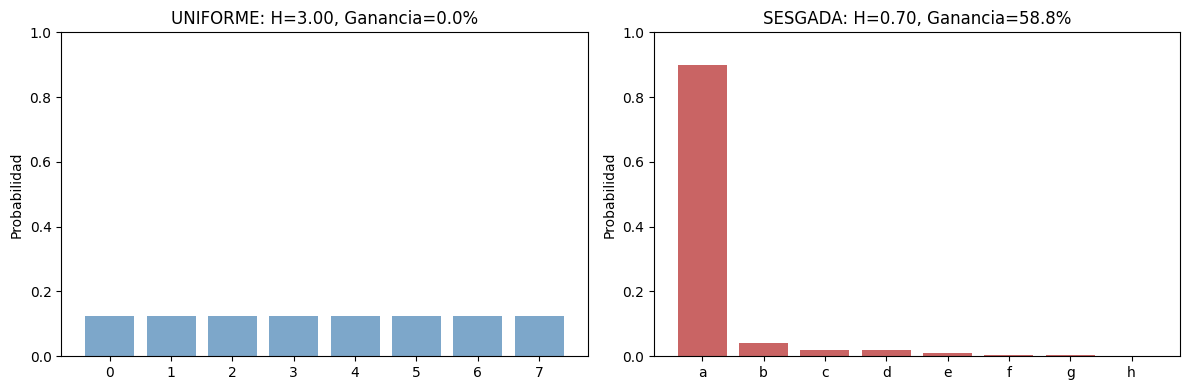

In [18]:
def analizar_fuente(nombre, freq_dict, p_dict):
    """Analiza una fuente: entropía, Huffman, ganancia."""
    K_f = len(p_dict)
    H_f = calcular_entropia(p_dict)
    B_fijo_f = math.ceil(math.log2(K_f))
    
    codec_f = Huffman(freq_dict)
    code_f = codec_f.codigo
    L_f = sum(p_dict[s] * len(code_f[s]) for s in p_dict)
    
    eta_f = H_f / L_f if L_f > 0 else 0
    ganancia_f = (B_fijo_f - L_f) / B_fijo_f * 100
    
    return {'nombre': nombre, 'K': K_f, 'H': H_f, 'B_fijo': B_fijo_f,
            'L': L_f, 'eta': eta_f, 'ganancia': ganancia_f, 'p': p_dict}

# Fuente A: Uniforme
K_test = 8
p_uniforme = {str(i): 1/K_test for i in range(K_test)}
freq_uniforme = {str(i): 1000 for i in range(K_test)}

# Fuente B: Muy sesgada
p_sesgada = {'a': 0.9, 'b': 0.04, 'c': 0.02, 'd': 0.02,
             'e': 0.01, 'f': 0.005, 'g': 0.003, 'h': 0.002}
freq_sesgada = {s: int(pr * 10000) for s, pr in p_sesgada.items()}

res_A = analizar_fuente('UNIFORME', freq_uniforme, p_uniforme)
res_B = analizar_fuente('SESGADA', freq_sesgada, p_sesgada)

# Tabla comparativa (alineación robusta en texto plano)
w_metric = 28
w_col = 16
line_w = w_metric + 2 * w_col

print("=" * line_w)
print("¿CUÁNDO VALE LA PENA HUFFMAN?".center(line_w))
print("=" * line_w)
print(f"{'Metrica':<{w_metric}}{'UNIFORME':>{w_col}}{'SESGADA':>{w_col}}")
print("-" * line_w)

filas = [
    ("Tamano alfabeto K", f"{res_A['K']}", f"{res_B['K']}"),
    ("Entropia H", f"{res_A['H']:.4f}", f"{res_B['H']:.4f}"),
    ("Bits codigo fijo", f"{res_A['B_fijo']}", f"{res_B['B_fijo']}"),
    ("Longitud media L", f"{res_A['L']:.4f}", f"{res_B['L']:.4f}"),
    ("Eficiencia eta=H/L", f"{res_A['eta']:.4f}", f"{res_B['eta']:.4f}"),
    ("Ganancia vs fijo", f"{res_A['ganancia']:.1f}%", f"{res_B['ganancia']:.1f}%"),
]

for metrica, v_a, v_b in filas:
    print(f"{metrica:<{w_metric}}{v_a:>{w_col}}{v_b:>{w_col}}")

print("=" * line_w)

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(p_uniforme.keys(), p_uniforme.values(), color='steelblue', alpha=0.7)
axes[0].set_title(f"UNIFORME: H={res_A['H']:.2f}, Ganancia={res_A['ganancia']:.1f}%")
axes[0].set_ylabel('Probabilidad')
axes[0].set_ylim([0, 1])

axes[1].bar(p_sesgada.keys(), p_sesgada.values(), color='firebrick', alpha=0.7)
axes[1].set_title(f"SESGADA: H={res_B['H']:.2f}, Ganancia={res_B['ganancia']:.1f}%")
axes[1].set_ylabel('Probabilidad')
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()


### ✍️ Explicación (OBLIGATORIA)

1. Explica esta afirmación: En una fuente uniforme se cumple que \(H \approx \log_2(K) = B_{fijo}\) y, por tanto, Huffman no ofrece ganancia alguna.

   En una fuente uniforme todos los símbolos tienen la misma probabilidad. Esto implica que la entropía es máxima y se aproxima a H=log2(K)
   que coincide con el número de bits de un código fijo. Por ello Huffman no puede reducir la longitud media y no existe ganancia.  

2. Explica esta afirmación: En una fuente sesgada se cumple que \(H \ll \log_2(K)\) y, por tanto, Huffman ofrece mucha ganancia
   
   En una fuente sesgada algunos símbolos aparecen mucho más que otros.
   Esto reduce la entropía porque hay menos incertidumbre. Huffman aprovecha esto asignando códigos cortos a los símbolos más frecuentes y largos a los menos frecuentes, lo que reduce la longitud media respecto al código fijo.

3. ¿Puede decirse que Huffman explota la desigualdad en las probabilidades de los símbolos para comprimir mejor?
   
   Sí. Huffman se basa precisamente en las diferencias de probabilidad entre símbolos. Cuanto más desigual es la distribución, más puede reducir la longitud media del código y mayor es la compresión obtenida.


---

### Bloque 4e · Codificación de imágenes

Calcularemos la entropía y ventaja que proporciona Huffman en 3 tipos de imágenes:
- Imagen sintética con píxeles aleatorios
- Imagen blanco y negro de una fotografía
- Imagen con la señal diferencia de la fotografía

In [19]:
# === Función auxiliar: análisis y codificación Huffman de una secuencia ===
# Reutilizable para imagen (píxeles), Lenna o señal diferencia

def analizar_y_codificar_huffman(secuencia, B_fijo=None):
    """
    Dado un array 1D (píxeles o diferencias), calcula frecuencias, probabilidades,
    entropía, código Huffman, longitud media y métricas de compresión.
    Si B_fijo es None, se usa ceil(log2(rango)) para el código fijo (p. ej. diferencias).
    """
    N = len(secuencia)
    freq = {}
    for x in secuencia:
        freq[x] = freq.get(x, 0) + 1
    p = {s: f / N for s, f in freq.items()}
    H = calcular_entropia(p)
    codec = Huffman(freq)
    code = codec.codigo
    L = sum(p[s] * len(code[s]) for s in p)
    K = len(p)
    if B_fijo is None:
        min_val = min(freq.keys())
        max_val = max(freq.keys())
        rango = max_val - min_val + 1
        B_fijo = int(np.ceil(np.log2(rango)))
    bits_fijo = N * B_fijo
    bits_huffman = sum(freq[s] * len(code[s]) for s in freq)
    ganancia = (bits_fijo - bits_huffman) / bits_fijo * 100
    return {
        'freq': freq, 'p': p, 'H': H, 'codec': codec, 'code': code, 'L': L,
        'K': K, 'B_fijo': B_fijo, 'bits_fijo': bits_fijo,
        'bits_huffman': bits_huffman, 'ganancia': ganancia, 'N': N
    }

In [20]:
# === Imagen sintética con píxeles aleatorios ===

# Imagen sintética 512x512 con distribución más uniforme
# Crear una distribución más plana generando píxeles aleatorios directamente
img_sintetica = np.random.randint(0, 256, size=(512, 512), dtype=np.uint8)

pixels = img_sintetica.flatten()
R_sintetica = analizar_y_codificar_huffman(pixels, B_fijo=8)


In [21]:
# === Imagen de una fotografía ===

# Cargar imagen Lenna512x512.png en escala de grises
img_color = imread('../helpers/Lenna512x512.png')

# Convertir a escala de grises si es necesario
if img_color.ndim == 3:
    # Asumir canal último, ponderar como luminancia estándar
    img_foto = (0.2989 * img_color[..., 0] +
           0.5870 * img_color[..., 1] +
           0.1140 * img_color[..., 2])
    img_foto = img_foto.astype(np.uint8) if img_foto.max() > 1 else (img_foto * 255).astype(np.uint8)
else:
    # Ya está en escala de grises o binaria
    img_foto = img_color.astype(np.uint8) if img_color.max() > 1 else (img_color * 255).astype(np.uint8)

pixels = img_foto.flatten()
R_foto = analizar_y_codificar_huffman(pixels, B_fijo=8)



In [22]:
# === Imagen real: señal diferencia ===

# Ya se cargó la imagen original arriba. Ahora trabajamos con la señal diferencia horizontal:
# Asumimos 'img' ya contiene la imagen en escala de grises
# Calculamos la señal de diferencias horizontales (por filas)
img_diff = img_foto[:, 1:].astype(np.int16) - img_foto[:, :-1].astype(np.int16)

pixels = img_diff.flatten()
# B_fijo=None → se calcula automáticamente según el rango de diferencias
R_diff = analizar_y_codificar_huffman(pixels, B_fijo=None)
min_val, max_val = min(R_diff['freq'].keys()), max(R_diff['freq'].keys())


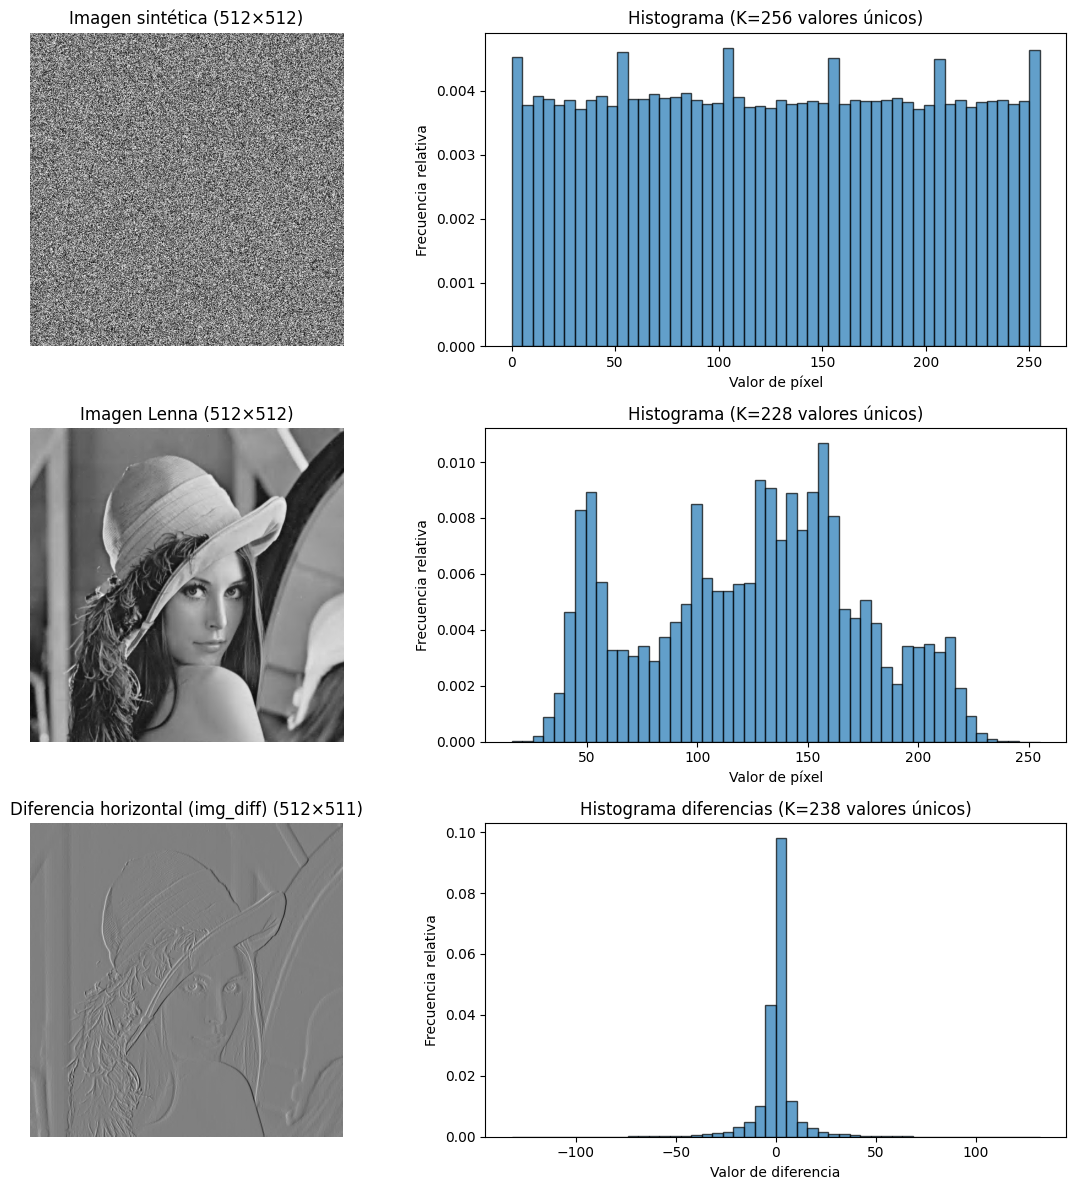

In [23]:
fig, axes = plt.subplots(3, 2, figsize=(12, 12))

# Fila 0: Imagen sintética
axes[0, 0].imshow(img_sintetica, cmap='gray')
axes[0, 0].set_title('Imagen sintética (512×512)')
axes[0, 0].axis('off')

pixels_sintetica = img_sintetica.flatten()
axes[0, 1].hist(pixels_sintetica, bins=50, density=True, alpha=0.7, edgecolor='black')
axes[0, 1].set_xlabel('Valor de píxel')
axes[0, 1].set_ylabel('Frecuencia relativa')
axes[0, 1].set_title(f'Histograma (K={R_sintetica["K"]} valores únicos)')

# Fila 1: Fotografía Lenna
axes[1, 0].imshow(img_foto, cmap='gray')
axes[1, 0].set_title(f'Imagen Lenna ({img_foto.shape[0]}×{img_foto.shape[1]})')
axes[1, 0].axis('off')

pixels_foto = img_foto.flatten()
axes[1, 1].hist(pixels_foto, bins=50, density=True, alpha=0.7, edgecolor='black')
axes[1, 1].set_xlabel('Valor de píxel')
axes[1, 1].set_ylabel('Frecuencia relativa')
axes[1, 1].set_title(f'Histograma (K={R_foto["K"]} valores únicos)')

# Fila 2: Señal diferencia
axes[2, 0].imshow(img_diff, cmap='gray', vmin=img_diff.min(), vmax=img_diff.max())
axes[2, 0].set_title(f'Diferencia horizontal (img_diff) ({img_diff.shape[0]}×{img_diff.shape[1]})')
axes[2, 0].axis('off')

pixels_diff = img_diff.flatten()
axes[2, 1].hist(pixels_diff, bins=50, density=True, alpha=0.7, edgecolor='black')
axes[2, 1].set_xlabel('Valor de diferencia')
axes[2, 1].set_ylabel('Frecuencia relativa')
axes[2, 1].set_title(f'Histograma diferencias (K={R_diff["K"]} valores únicos)')

plt.tight_layout()
plt.show()

In [24]:
# === TABLA COMPARATIVA DE COMPRESIÓN ===

print("\n" + "="*90)
print("COMPARACIÓN DE COMPRESIÓN: IMAGEN SINTÉTICA, FOTOGRAFÍA Y SEÑAL DIFERENCIA")
print("="*90)

# Crear tabla con datos
data = {
    'Métrica': [
        'Tamaño (píxeles)',
        'Valores únicos (K)',
        'Entropía H (bits/elem)',
        'Código fijo (bits/elem)',
        'Longitud media Huffman (bits/elem)',
        'Bits totales (código fijo)',
        'Bits totales (Huffman)',
        'Ganancia (%)'
    ],
    'Imagen Sintética': [
        f"{R_sintetica['N']:,}",
        f"{R_sintetica['K']}",
        f"{R_sintetica['H']:.2f}",
        f"{R_sintetica['B_fijo']}",
        f"{R_sintetica['L']:.4f}",
        f"{R_sintetica['bits_fijo']:,}",
        f"{R_sintetica['bits_huffman']:,}",
        f"{R_sintetica['ganancia']:.2f}%"
    ],
    'Fotografía (Lenna)': [
        f"{R_foto['N']:,}",
        f"{R_foto['K']}",
        f"{R_foto['H']:.2f}",
        f"{R_foto['B_fijo']}",
        f"{R_foto['L']:.4f}",
        f"{R_foto['bits_fijo']:,}",
        f"{R_foto['bits_huffman']:,}",
        f"{R_foto['ganancia']:.2f}%"
    ],
    'Señal Diferencia': [
        f"{R_diff['N']:,}",
        f"{R_diff['K']}",
        f"{R_diff['H']:.2f}",
        f"{R_diff['B_fijo']}",
        f"{R_diff['L']:.4f}",
        f"{R_diff['bits_fijo']:,}",
        f"{R_diff['bits_huffman']:,}",
        f"{R_diff['ganancia']:.2f}%"
    ]
}

df_comparacion = pd.DataFrame(data)
print(df_comparacion.to_string(index=False))
print("="*90)




COMPARACIÓN DE COMPRESIÓN: IMAGEN SINTÉTICA, FOTOGRAFÍA Y SEÑAL DIFERENCIA
                           Métrica Imagen Sintética Fotografía (Lenna) Señal Diferencia
                  Tamaño (píxeles)          262,144            262,144          261,632
                Valores únicos (K)              256                228              238
            Entropía H (bits/elem)             8.00               7.45             4.52
           Código fijo (bits/elem)                8                  8                9
Longitud media Huffman (bits/elem)           8.0000             7.4794           4.5381
        Bits totales (código fijo)        2,097,152          2,097,152        2,354,688
            Bits totales (Huffman)        2,097,152          1,960,672        1,187,310
                      Ganancia (%)            0.00%              6.51%           49.58%


### ✍️ Explicación (OBLIGATORIA)

1. Observa la entropia de cada imagen y relacionala con su histograma.

   *Tu respuesta:*

2. ¿Qué representa el histograma y por qué tiene esa forma en cada caso?

   *Tu respuesta:*

3. ¿Qué imagen tiene menos entropía? ¿Por qué?

   *Tu respuesta:*

4. Explica con tus palabras como se te ocurre que podrías detectar la imagen con mayor información.

   *Tu respuesta:*

### 🔍 Checkpoint del profesor

- [ ] Código Huffman construido con $\eta$ y $\bar{L}$ calculados
- [ ] $H \leq \bar{L} < H + 1$ verificado (Primer Teorema de Shannon)
- [ ] Comparación uniforme vs sesgada completada con gráficas
- [ ] Análisis de la entropía y Huffman con 3 imágenes diferentes

---

## Preguntas de control

Responde cada pregunta en 2–6 líneas:

### P1. ¿Qué diferencia conceptual hay entre auto-información $I(s)$ y entropía $H$?

*Tu respuesta:*

### P2. ¿Qué diferencia conceptual hay entre entropía $H$ y longitud media $\bar{L}$ de un código concreto?

*Tu respuesta:*

### P3. ¿Por qué Huffman es óptimo respecto a los códigos fijos?

*Tu respuesta:*

### P4. ¿Qué ocurre con $H$, $\bar{L}$ y la ganancia cuando la fuente es casi equiprobable?

*Tu respuesta:*

### P5. Extrapola los conceptos de relación de entropía y probabilidades al caso de las imágenes. Explica porque la entropía es mayor o menor en cada caso.

*Tu respuesta:*